In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

### Config

In [2]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

### 1. Load Data with Augmentation

In [3]:
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory('data/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse')
val_gen = val_datagen.flow_from_directory('data/val', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse')

Found 93 images belonging to 5 classes.
Found 25 images belonging to 5 classes.


In [4]:
train_gen.class_indices.keys()

dict_keys(['ben_afflek', 'elton_john', 'jerry_seinfeld', 'madonna', 'mindy_kaling'])

### 2. Build Model (Transfer Learning)

In [5]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(len(train_gen.class_indices), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### 3. Train and Save

In [25]:
model.fit(train_gen, validation_data=val_gen, epochs=100) # Cambié a 20 epocas para mejorar la precision
model.save('modelo-celebridades.h5')

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 711ms/step - accuracy: 1.0000 - loss: 0.0390 - val_accuracy: 0.9600 - val_loss: 0.3454
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 623ms/step - accuracy: 1.0000 - loss: 0.0357 - val_accuracy: 0.9600 - val_loss: 0.3468
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 621ms/step - accuracy: 1.0000 - loss: 0.0337 - val_accuracy: 0.9600 - val_loss: 0.3478
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 596ms/step - accuracy: 1.0000 - loss: 0.0388 - val_accuracy: 0.9600 - val_loss: 0.3474
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 594ms/step - accuracy: 1.0000 - loss: 0.0334 - val_accuracy: 0.9600 - val_loss: 0.3444
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 649ms/step - accuracy: 1.0000 - loss: 0.0316 - val_accuracy: 0.9600 - val_loss: 0.3404
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 590ms/step - accuracy: 1.0000 - loss: 0.0364 - val_accuracy: 0.9600 - val_loss: 0.3349
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 579ms/step - accuracy: 1.0000 - loss: 0.0327 - val_accuracy: 0.9600 - v

### Store class names for prediction

In [26]:
class_names = list(train_gen.class_indices.keys())
print("Classes identified:", class_names)

Classes identified: ['ben_afflek', 'elton_john', 'jerry_seinfeld', 'madonna', 'mindy_kaling']


## PROBANDO EL MODELO

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


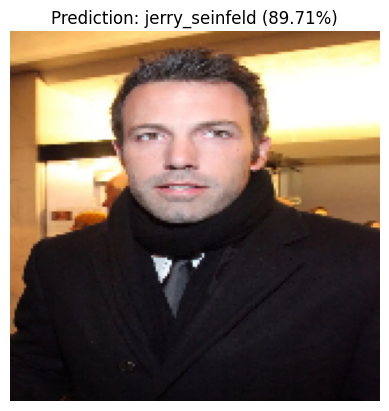

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


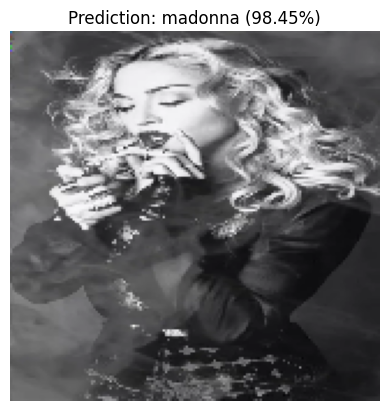

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


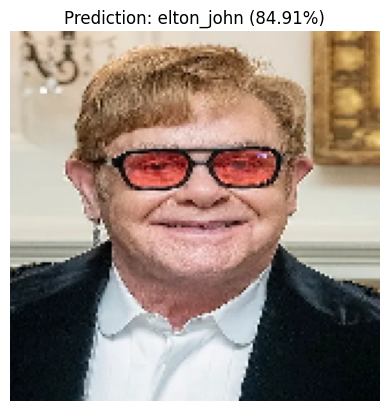

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


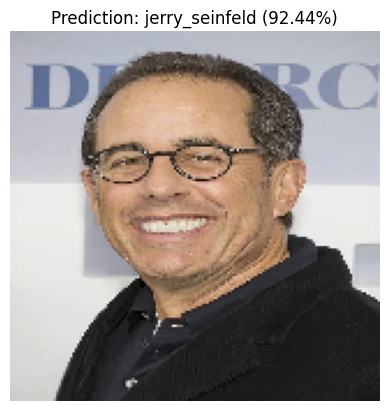

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


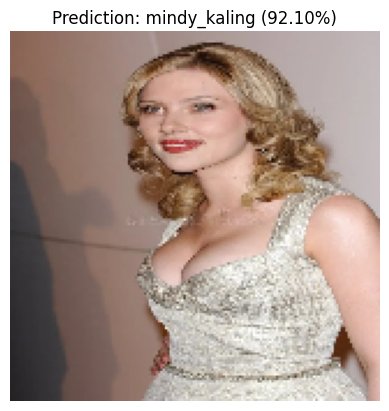

In [27]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_celebrity(img_path, model_path='modelo-celebridades.h5'):
    # Load model and image
    model = tf.keras.models.load_model(model_path)
    img = image.load_img(img_path, target_size=(160, 160))
    
    # Pre-process
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0) # Create batch axis

    # Predict
    predictions = model.predict(img_array)
    score = np.max(predictions)
    class_idx = np.argmax(predictions)
    
    # Display
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[class_idx]} ({100 * score:.2f}%)")
    plt.axis('off')
    plt.show()

# Usage:
predict_celebrity('Ben.webp')
predict_celebrity('Madonna.jpg')
predict_celebrity('Elton.webp')
predict_celebrity('Jerry.webp')
predict_celebrity('Scarlet.webp')